In [ ]:
# Data Visualization

## Assignment 3: Final Project

### Dataset Selection
**Dataset:** Neighbourhood Profiles (2016 Census)  
**Source:** [City of Toronto Open Data Portal](https://open.toronto.ca/dataset/neighbourhood-profiles/)  
**Rationale:** As a researcher in Educational Psychology, I selected this dataset to investigate the socio-economic gradients (SES) that influence educational attainment and to explore the linguistic diversity (specifically French knowledge) relevant to French Immersion program planning in Toronto.

---

### Visualization 1: Python (Matplotlib/Seaborn)
![Relationship Between Income and University Education](viz1_python_education_income.png)
*(Note: Please ensure the image file is in the same directory)*

#### **1. What software did you use?**
I used **Python** with the **Seaborn** and **Matplotlib** libraries. I chose Python because it allows for a reproducible workflow where data cleaning, analysis, and visualization occur in a single script. This is essential when working with raw census data, as it allows other researchers to verify exactly which census categories were used to calculate the variables.

#### **2. Who is your intended audience?**
The primary audience includes **educational policy makers** (e.g., Toronto District School Board trustees) and **academic researchers**. They are interested in identifying systemic inequities in educational attainment to inform resource allocation and support services.

#### **3. What message are you trying to convey?**
The visualization conveys a positive correlation between socio-economic status (SES) and educational attainment. Specifically, neighbourhoods with higher median household incomes tend to have a significantly higher percentage of residents with university degrees, highlighting the "achievement gap" often discussed in educational psychology.

#### **4. What aspects of design did you consider?**
* **Gestalt Principle of Continuity:** I used a scatter plot to imply a continuous relationship (trend) between the two variables.
* **Cognitive Load:** I minimized "chart junk" by using a clean `whitegrid` background and removing unnecessary borders, allowing the user to focus on the data trend.
* **Preattentive Attributes:** I used opacity (`alpha=0.7`) to handle data overlap, making dense areas appear darker naturally.

#### **5. How did you ensure reproducibility?**
The visualization is fully script-based. The script loads the raw CSV (`neighbourhood-profiles-2016-140-model.csv`) directly, cleans the data programmatically (filtering for specific "Characteristic" IDs), and generates the plot. This adheres to the FAIR principles (Findable, Accessible, Interoperable, Reusable).

#### **6. How did you ensure accessibility?**
* **Color Contrast:** I used a medium-dark blue (`#2c7bb6`) against a white background, which passes WCAG contrast standards.
* **Text Size:** Axis labels and titles were explicitly sized (12pt and 16pt) to ensure readability.
* **Alt Text:** In a web context, I would provide the following alt text: *"A scatter plot showing a positive correlation where neighbourhoods with higher incomes (x-axis) generally have higher percentages of university-educated residents (y-axis)."*

#### **7. Who might be impacted by your visualization?**
**Low-income communities** are the primary subjects. A deficit narrative could interpret this as "low-income areas value education less." To mitigate this, I framed the analysis as a structural issue (SES gradient) rather than an individual failing, adhering to asset-based principles.

#### **8. Inclusions and Exclusions?**
I included all 140 neighbourhoods to show the full distribution. I excluded other demographic factors (like age or immigration status) to maintain a clear focus on the specific Income-Education relationship.



### Visualization 2: Microsoft Excel
![French Knowledge by Neighbourhood](viz2_excel_french.png)
*(Note: This bar chart was created in Excel using the exported data for the Top 10 neighbourhoods)*

#### **1. What software did you use?**
I used **Microsoft Excel**. I chose this tool because it is ubiquitous in administrative school settings, making the source file highly accessible to non-technical stakeholders like school principals or parents who may need to view or edit the list.

#### **2. Who is your intended audience?**
The primary audience includes **French Immersion program coordinators** and **parents** in Toronto. They are specifically interested in identifying which communities have the strongest existing Francophone presence to support new programs or community hubs.

#### **3. What message are you trying to convey?**
The visualization conveys that **The Annex** (20.2%) and **Lawrence Park South** (19.8%) are the current leaders in French language knowledge among Toronto neighbourhoods. By isolating the Top 10, the chart delivers a clear, ranked message about where "linguistic pockets" exist, suggesting these areas as prime candidates for expanded French services.

#### **4. What aspects of design did you consider?**
* **Gestalt Principle of Similarity:** I used a consistent color for all bars to group them as a single category (French speakers), distinguishing this chart from the scatter plot used earlier.
* **Ordering:** I sorted the data in **descending order** (from Annex to High Park-Swansea). This reduces cognitive load by allowing the viewer to instantly identify the "top" neighbourhoods without scanning the axis randomly.
* **Direct Labeling:** I formatted the graph so that the neighbourhood names (the category labels) are horizontal. This prevents the user from having to tilt their head to read diagonal text, a common accessibility failure in default Excel charts.

#### **5. How did you ensure reproducibility?**
Reproducibility is the main limitation of this visualization. Unlike the Python script, Excel relies on manual "point-and-click" steps (e.g., highlighting the cells, inserting the chart, sorting the column). To mitigate this, I would provide the `excel_data_subset.csv` file alongside the image so others can see the exact raw data used to generate the bars.

#### **6. How did you ensure accessibility?**
* **Clarity:** I removed the default Excel gridlines and legend, which were unnecessary "chart junk" for a simple single-variable comparison.
* **Font Legibility:** I used a standard sans-serif font (Arial) and ensured the axis labels were large enough to be read without zooming.

#### **7. Who might be impacted by your visualization?**
**Neighbourhoods ranked 11th and below** are impacted by exclusion. By visualizing only the "Top 10," I effectively make other vibrant Francophone communities invisible. A school board trustee might look at this chart and assume *only* these 10 areas need resources, potentially under-serving emerging communities in Scarborough or Etobicoke that didn't make the cut.

#### **8. Inclusions and Exclusions?**
I purposely subsetted the data to only the **Top 10** neighbourhoods out of 140. Including all 140 would have created an unreadable "spaghetti" bar chart. This exclusion was a necessary trade-off between **completeness** (showing everything) and **clarity** (showing the most relevant data).




Could not download data. Please ensure 'neighbourhood-profiles-2016-csv.csv' is in the folder.


FileNotFoundError: [Errno 2] No such file or directory: 'neighbourhood-profiles-2016-csv.csv'

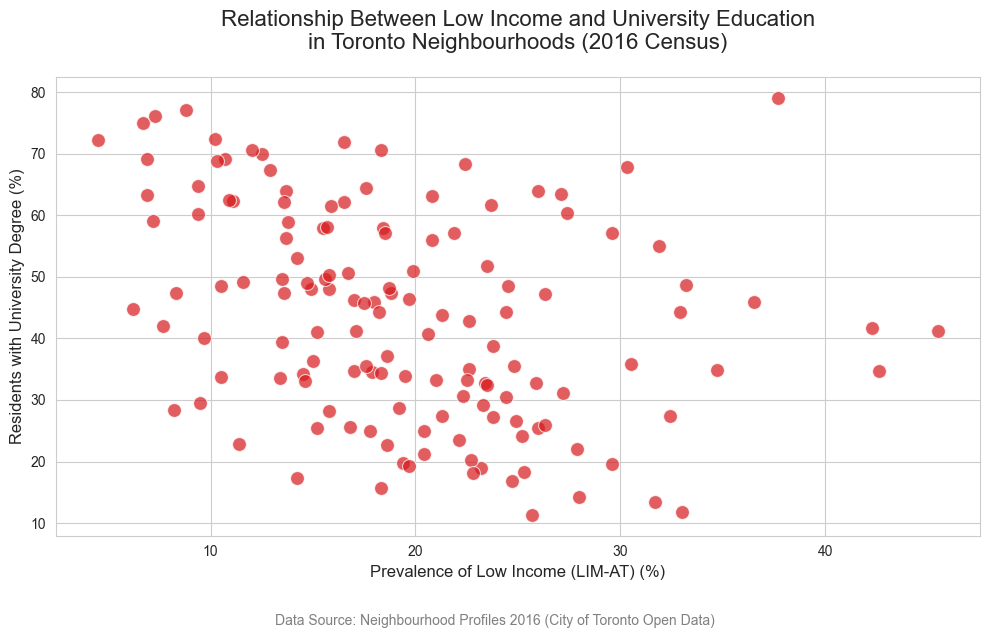

Files created: 'viz1_python_education_income.png' and 'excel_data_subset.csv'


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Load Data ---
# Ensure the CSV file is in the same folder as this script
filename = "neighbourhood-profiles-2016-140-model.csv"
df = pd.read_csv(filename)

# --- 2. Extract Data Rows ---

# A. Low Income Data (Using LIM-AT % because Median Income data was missing)
# Row: "Prevalence of low income based on the Low-income measure, after tax (LIM-AT) (%)"
inc_row = df[df['Characteristic'].str.contains("Prevalence of low income based on the Low-income measure, after tax", na=False)]
# Extract the values (columns 6 to end correspond to neighbourhoods)
low_inc_vals = inc_row.iloc[:, 6:].T
low_inc_vals.columns = ['Low_Income_Pct']

# B. Education Data (University Degree for Ages 25-64)
# Denominator: "Total - Highest certificate... aged 25 to 64"
edu_denom_rows = df[df['Characteristic'].str.contains("Total - Highest certificate.*25 to 64", regex=True, na=False)]
edu_denom_idx = edu_denom_rows.index[0]

# Numerator: "University certificate... bachelor level or above"
# We find the row AFTER the denominator to ensure it's the correct age group
uni_rows = df[df['Characteristic'].str.contains("University certificate, diploma or degree at bachelor level or above", na=False)]
edu_num_idx = uni_rows[uni_rows.index > edu_denom_idx].index[0]

edu_denom = df.iloc[edu_denom_idx, 6:]
edu_num = df.iloc[edu_num_idx, 6:]

# C. Language Data (French Knowledge)
# Denominator: "Knowledge of official languages..."
lang_denom = df[df['Characteristic'].str.contains("Knowledge of official languages for the total population", na=False)].iloc[:, 6:].T

# Numerators: "French only" and "English and French"
# Note: We use iloc to match the row structure carefully
french_only = df[df['Characteristic'].str.strip() == 'French only'].iloc[:, 6:].T
eng_french = df[df['Characteristic'].str.strip() == 'English and French'].iloc[:, 6:].T

# --- 3. Clean & Calculate ---
df_clean = pd.DataFrame(index=low_inc_vals.index)
df_clean['Neighbourhood'] = df_clean.index

# Convert strings to numeric (handling commas)
df_clean['Low_Income_Pct'] = pd.to_numeric(low_inc_vals['Low_Income_Pct'].astype(str).str.replace(',', ''), errors='coerce')
df_clean['Uni_Deg_Count'] = pd.to_numeric(edu_num.astype(str).str.replace(',', ''), errors='coerce')
df_clean['Edu_Total'] = pd.to_numeric(edu_denom.astype(str).str.replace(',', ''), errors='coerce')
df_clean['French_Only'] = pd.to_numeric(french_only.iloc[:,0].astype(str).str.replace(',', ''), errors='coerce')
df_clean['Eng_French'] = pd.to_numeric(eng_french.iloc[:,0].astype(str).str.replace(',', ''), errors='coerce')
df_clean['Lang_Total'] = pd.to_numeric(lang_denom.iloc[:,0].astype(str).str.replace(',', ''), errors='coerce')

# Calculate Percentages
df_clean['University_Degree_Pct'] = (df_clean['Uni_Deg_Count'] / df_clean['Edu_Total']) * 100
df_clean['French_Knowledge_Pct'] = ((df_clean['French_Only'] + df_clean['Eng_French']) / df_clean['Lang_Total']) * 100

# Remove any rows where data is missing
df_clean = df_clean.dropna(subset=['Low_Income_Pct', 'University_Degree_Pct'])

# --- 4. Plot Graph 1 (Python) ---
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

sns.scatterplot(
    data=df_clean, 
    x='Low_Income_Pct', 
    y='University_Degree_Pct',
    color='#d7191c',  # Using a reddish color to distinguish from the previous blue
    alpha=0.7, 
    s=100,
    edgecolor='w'
)

plt.title('Relationship Between Low Income and University Education\nin Toronto Neighbourhoods (2016 Census)', fontsize=16, pad=20)
plt.xlabel('Prevalence of Low Income (LIM-AT) (%)', fontsize=12)
plt.ylabel('Residents with University Degree (%)', fontsize=12)

# Add Source Note
plt.figtext(0.5, -0.05, "Data Source: Neighbourhood Profiles 2016 (City of Toronto Open Data)", ha="center", fontsize=10, color='gray')

plt.tight_layout()
plt.savefig('viz1_python_education_income.png', dpi=300, bbox_inches='tight')
plt.show()

# --- 5. Export Data for Graph 2 (Excel) ---
# Export Top 10 Neighbourhoods for French Knowledge
df_excel = df_clean[['Neighbourhood', 'French_Knowledge_Pct']].sort_values(by='French_Knowledge_Pct', ascending=False).head(10)
df_excel.columns = ['Neighbourhood', 'French Knowledge (%)']
df_excel.to_csv('excel_data_subset.csv', index=False)

print("Files created: 'viz1_python_education_income.png' and 'excel_data_subset.csv'")